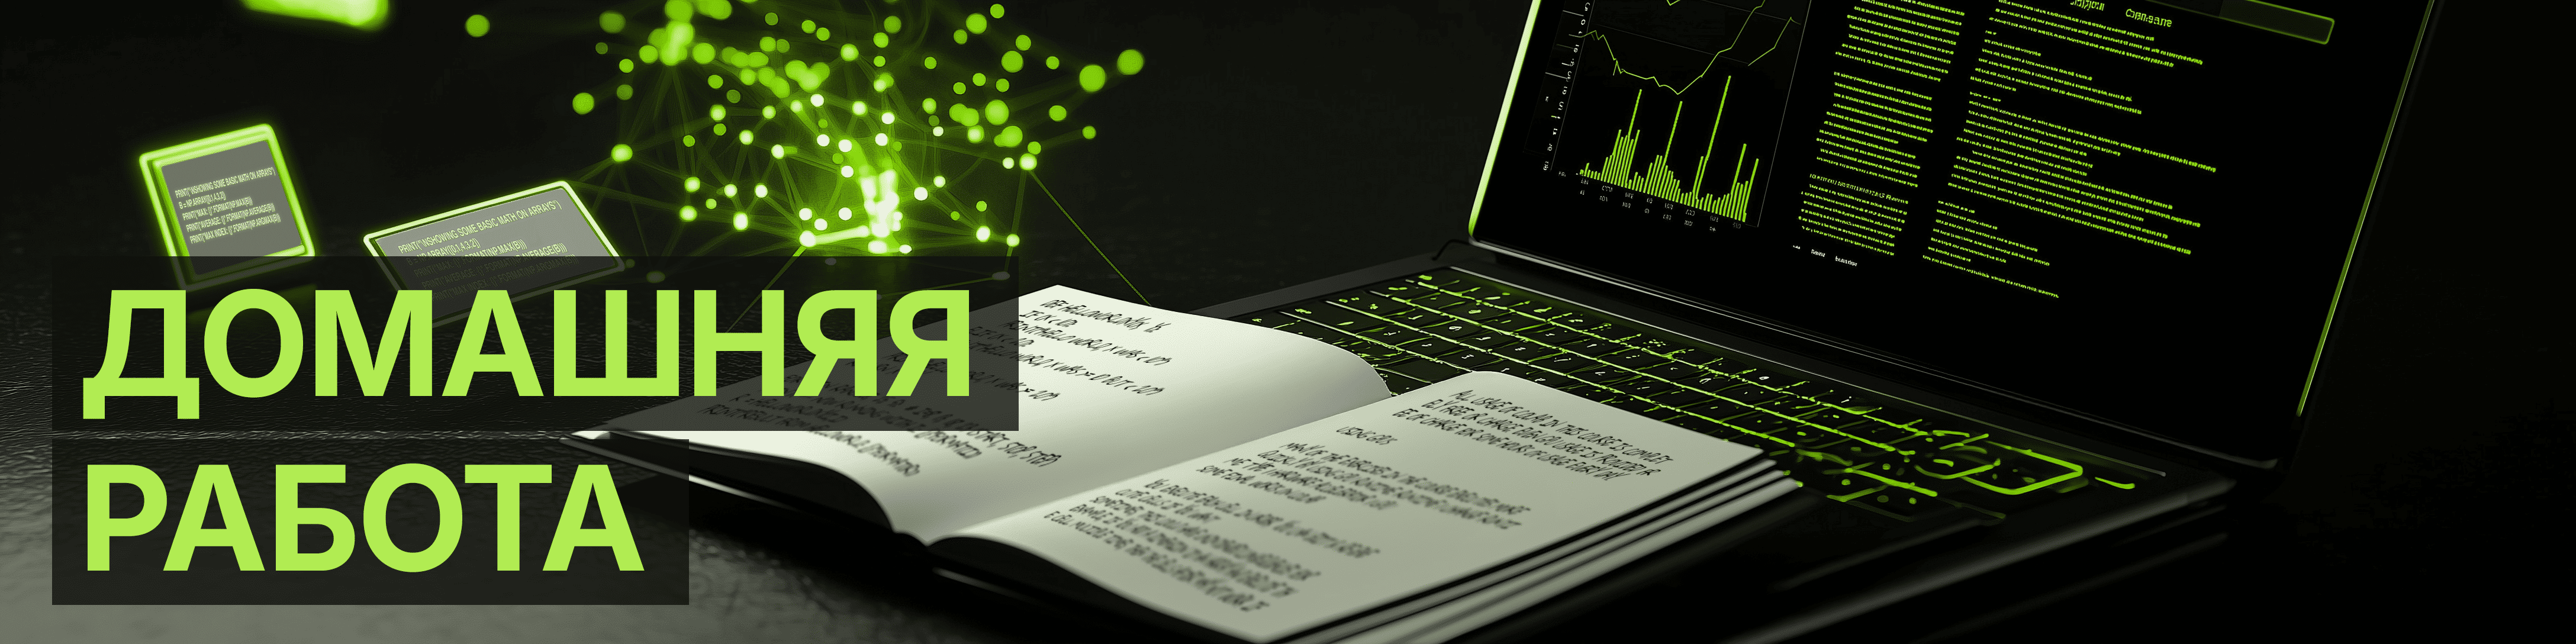

**Навигация по уроку**
1. [Автокодировщик GAN. Генеративно-состязательные сети](https://colab.research.google.com/drive/15hs_BV9OGUuaTmVetqYaAUf8zpDgxz3_)
2. [Сверточные GAN. Генерация фейковых лиц](https://colab.research.google.com/drive/1mCDkjVfw4-ZWysmat7LH-xAmssZj6ANU)
3. [CyrcleGAN. Создаем картины в стиле Моне](https://colab.research.google.com/drive/1SKpzFYFsiU53E1BpRS4waNzQ_mVk-XMz)
4. Домашняя работа

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:

**Задание 1. На 3 балла:**

1. Ваша задача, используя датасет MNIST (из набора датасетов Tensorflow) научить GAN генерировать цифры.

2. Добейтесь хорошего качества генерации.

**Задание 2. На 4 балла:**

1. Ваша задача, используя датасет MNIST Fashion (из набора датасетов Tensorflow) научить GAN генерировать образцы одежды, соответственно.

2. Добейтесь хорошего качества генерации.

**Задание 3. На 5 баллов:**

1. Ваша задача, провести небольшое научное исследование, используя датасет MNIST Fashion (из набора датасетов Tensorflow) сравнить 2 разных модели DCGAN.

2. Необходимо, используя 2 разных генератора: классического GAN (на рис. 2. второй части урока) и улучшенного (из примера по генерации фейковых лиц), научить GAN генерировать образцы одежды.

2. Добейтесь хорошего качества генерации. Сравнить обе модели, сделайте выводы.

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28)
Test: (10000, 28, 28)
Изображений для GAN: (40000, 28, 28)
Форма: (40000, 28, 28, 1)
Минимум: -1.0
Максимум: 1.0
Количество батчей: 156


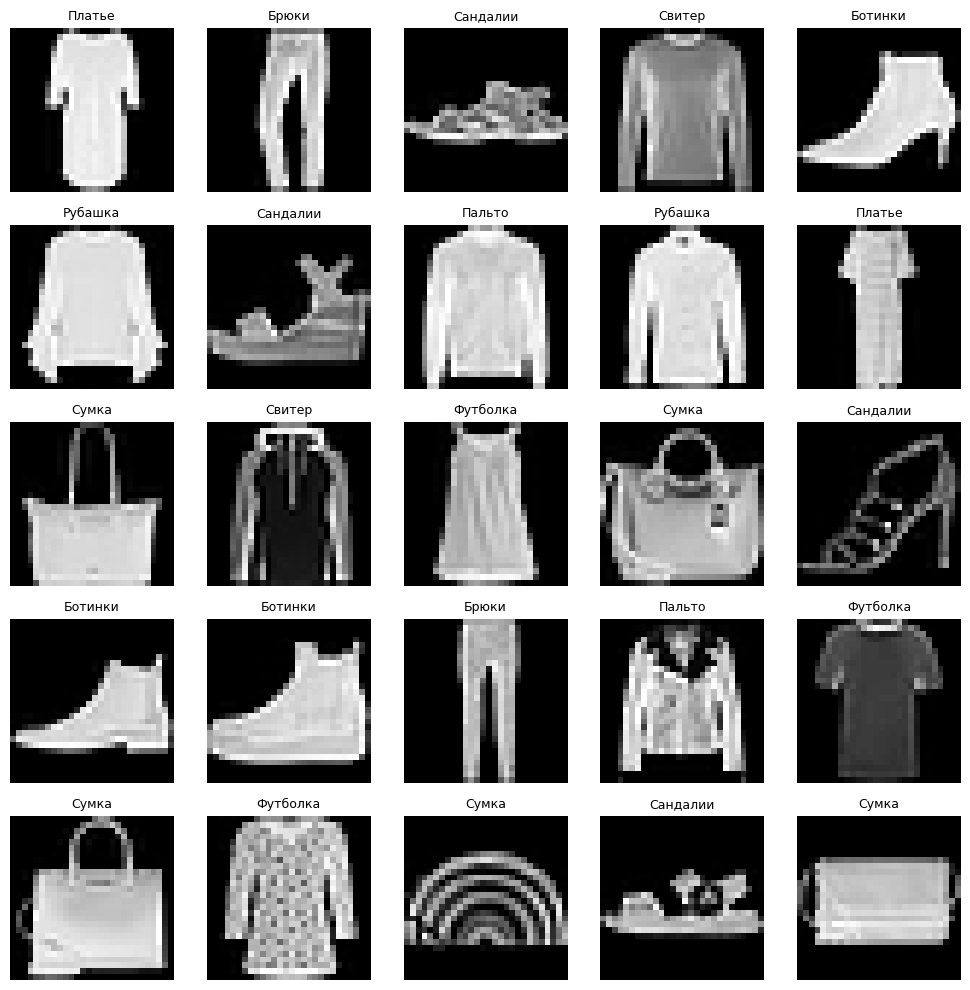

Форма батча: (256, 28, 28, 1)
Диапазон: -1.0 - 1.0


In [1]:
# 1. Импорты

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist


# 2. Настройки эксперимента

SEED = 42

TRAIN_LIMIT = 40000
BATCH_SIZE = 256
EPOCHS = 20
LATENT_DIM = 100

LEARNING_RATE = 0.0002
BETA_1 = 0.5

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(
    "TensorFlow:",
    tf.__version__
)

print(
    "GPU:",
    tf.config.list_physical_devices("GPU")
)


# 3. Загрузка Fashion MNIST

(
    train_images,
    train_labels,
), (
    test_images,
    test_labels,
) = fashion_mnist.load_data()

print(
    "Train:",
    train_images.shape
)

print(
    "Test:",
    test_images.shape
)


# 4. Выбор обучающих изображений

rng = np.random.default_rng(
    SEED
)

indices = rng.permutation(
    len(train_images)
)

indices = indices[
    :TRAIN_LIMIT
]

gan_images = train_images[
    indices
]

gan_labels = train_labels[
    indices
]

print(
    "Изображений для GAN:",
    gan_images.shape
)


# 5. Нормализация изображений

gan_images = (
    gan_images.astype(
        np.float32
    )
    - 127.5
) / 127.5

gan_images = np.expand_dims(
    gan_images,
    axis=-1,
)

print(
    "Форма:",
    gan_images.shape
)

print(
    "Минимум:",
    gan_images.min()
)

print(
    "Максимум:",
    gan_images.max()
)


# 6. Создание датасета

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        gan_images
    )
    .shuffle(
        TRAIN_LIMIT,
        seed=SEED,
        reshuffle_each_iteration=True,
    )
    .batch(
        BATCH_SIZE,
        drop_remainder=True,
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

print(
    "Количество батчей:",
    len(train_dataset)
)


# 7. Названия классов

class_names = [
    "Футболка",
    "Брюки",
    "Свитер",
    "Платье",
    "Пальто",
    "Сандалии",
    "Рубашка",
    "Кроссовки",
    "Сумка",
    "Ботинки",
]


# 8. Просмотр данных

plt.figure(
    figsize=(10, 10)
)

for index in range(25):

    image = (
        gan_images[
            index,
            :,
            :,
            0
        ]
        + 1.0
    ) / 2.0

    plt.subplot(
        5,
        5,
        index + 1,
    )

    plt.imshow(
        image,
        cmap="gray",
    )

    plt.title(
        class_names[
            gan_labels[index]
        ],
        fontsize=9,
    )

    plt.axis(
        "off"
    )

plt.tight_layout()
plt.show()


# 9. Проверка батча

for batch in train_dataset.take(1):

    print(
        "Форма батча:",
        batch.shape
    )

    print(
        "Диапазон:",
        float(
            tf.reduce_min(batch)
        ),
        "-",
        float(
            tf.reduce_max(batch)
        ),
    )





Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,073 (543.25 KB)

 Trainable params: 138,817 (542.25 KB)

 Non-trainable params: 256 (1.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       262,144 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,047,297 (4.00 MB)

 Trainable params: 1,034,369 (3.95 MB)

 Non-trainable params: 12,928 (50.50 KB)

Форма: (16, 28, 28, 1)
Диапазон: -0.0994362086057663 - 0.09693624824285507


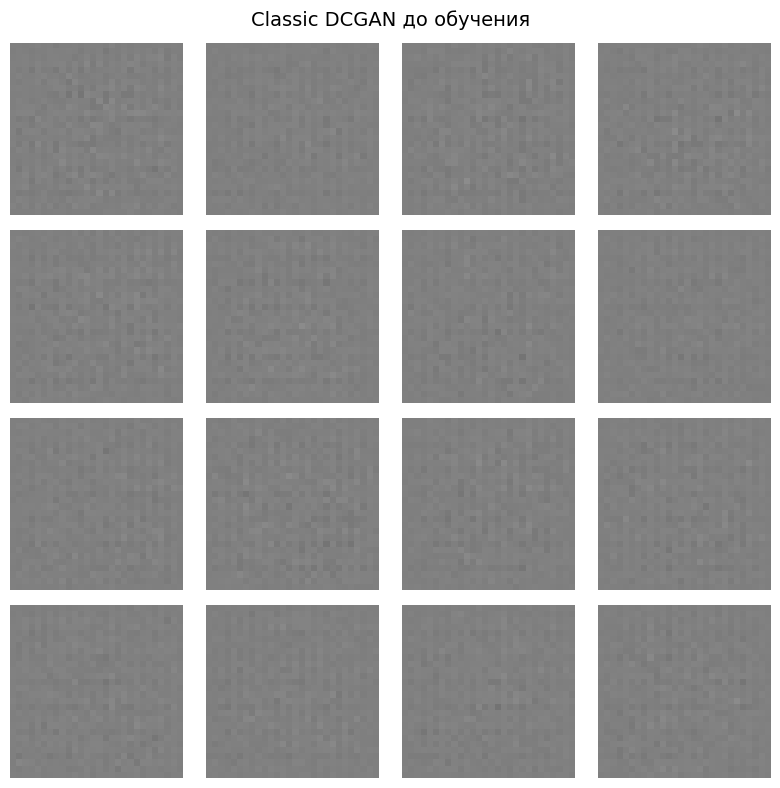

Шум: (16, 100)
Изображения: (16, 28, 28, 1)
Оценка дискриминатора: (16, 1)


In [2]:
# 10. Импорты для моделей

from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Conv2DTranspose,
    Dense,
    Dropout,
    Flatten,
    Input,
    LeakyReLU,
    Reshape,
)
from tensorflow.keras.optimizers import Adam


# 11. Общий дискриминатор

def create_discriminator():

    model = Sequential(
        name="Discriminator"
    )

    model.add(
        Input(
            shape=(28, 28, 1)
        )
    )

    model.add(
        Conv2D(
            64,
            kernel_size=4,
            strides=2,
            padding="same",
        )
    )

    model.add(
        LeakyReLU(
            negative_slope=0.2
        )
    )

    model.add(
        Dropout(0.3)
    )

    model.add(
        Conv2D(
            128,
            kernel_size=4,
            strides=2,
            padding="same",
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        LeakyReLU(
            negative_slope=0.2
        )
    )

    model.add(
        Dropout(0.3)
    )

    model.add(
        Flatten()
    )

    model.add(
        Dense(
            1,
            activation="sigmoid",
        )
    )

    return model



# 12. Проверка дискриминатора

discriminator_test = (
    create_discriminator()
)

discriminator_test.summary()



# 13. Тест дискриминатора

for batch in train_dataset.take(1):

    result = discriminator_test(
        batch,
        training=False,
    )

    print(
        "Вход:",
        batch.shape
    )

    print(
        "Выход:",
        result.shape
    )

    print(
        "Минимум:",
        float(
            tf.reduce_min(result)
        )
    )

    print(
        "Максимум:",
        float(
            tf.reduce_max(result)
        )
    )



# 14. Классический генератор

def create_classic_generator():

    model = Sequential(
        name="Classic_Generator"
    )

    model.add(
        Input(
            shape=(LATENT_DIM,)
        )
    )

    model.add(
        Dense(
            7 * 7 * 128,
            use_bias=False,
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        LeakyReLU(
            negative_slope=0.2
        )
    )

    model.add(
        Reshape(
            (7, 7, 128)
        )
    )

    model.add(
        Conv2DTranspose(
            128,
            kernel_size=4,
            strides=1,
            padding="same",
            use_bias=False,
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        LeakyReLU(
            negative_slope=0.2
        )
    )

    model.add(
        Conv2DTranspose(
            64,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        LeakyReLU(
            negative_slope=0.2
        )
    )

    model.add(
        Conv2DTranspose(
            1,
            kernel_size=4,
            strides=2,
            padding="same",
            activation="tanh",
        )
    )

    return model




# 15. Создание классического генератора

classic_generator = (
    create_classic_generator()
)

classic_generator.summary()



# 16. Генерация до обучения

test_noise = tf.random.normal(
    (
        16,
        LATENT_DIM,
    ),
    seed=SEED,
)

generated_images = (
    classic_generator(
        test_noise,
        training=False,
    )
)

print(
    "Форма:",
    generated_images.shape
)

print(
    "Диапазон:",
    float(
        tf.reduce_min(
            generated_images
        )
    ),
    "-",
    float(
        tf.reduce_max(
            generated_images
        )
    ),
)



# 17. Результат до обучения

plt.figure(
    figsize=(8, 8)
)

for index in range(16):

    image = generated_images[
        index,
        :,
        :,
        0
    ]

    image = (
        image + 1.0
    ) / 2.0

    plt.subplot(
        4,
        4,
        index + 1,
    )

    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    plt.axis("off")

plt.suptitle(
    "Classic DCGAN до обучения",
    fontsize=14,
)

plt.tight_layout()
plt.show()



# 18. Проверка связки моделей

fake_images = classic_generator(
    test_noise,
    training=False,
)

fake_predictions = (
    discriminator_test(
        fake_images,
        training=False,
    )
)

print(
    "Шум:",
    test_noise.shape
)

print(
    "Изображения:",
    fake_images.shape
)

print(
    "Оценка дискриминатора:",
    fake_predictions.shape
)




Model: "Improved_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 128)    │       262,144 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,830,721 (6.98 MB)

 Trainable params: 1,804,993 (6.89 MB)

 Non-trainable params: 25,728 (100.50 KB)

Форма: (16, 28, 28, 1)
Диапазон: -0.031194956973195076 - 0.04020015895366669


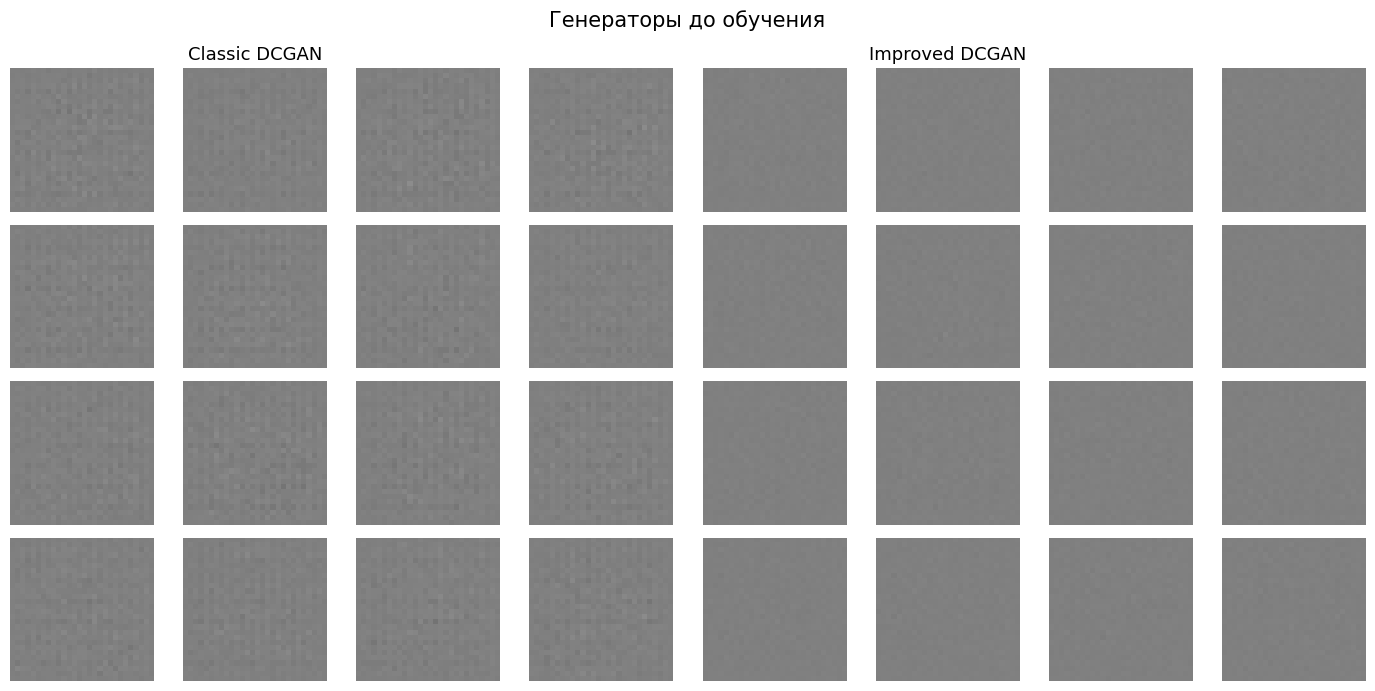

Classic Generator: 1,047,297 параметров
Improved Generator: 1,830,721 параметров

Разница: 783,424 параметров
Fixed noise: (25, 100)


In [3]:
# 19. Улучшенный генератор

def create_improved_generator():

    model = Sequential(
        name="Improved_Generator"
    )

    model.add(
        Input(
            shape=(LATENT_DIM,)
        )
    )

    model.add(
        Dense(
            14 * 14 * 64,
            use_bias=False,
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        LeakyReLU(
            negative_slope=0.2
        )
    )

    model.add(
        Reshape(
            (14, 14, 64)
        )
    )

    # Предварительное извлечение признаков
    model.add(
        Conv2D(
            128,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        LeakyReLU(
            negative_slope=0.2
        )
    )

    # Восстановление размерности
    model.add(
        Conv2DTranspose(
            128,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        LeakyReLU(
            negative_slope=0.2
        )
    )

    model.add(
        Conv2DTranspose(
            64,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
        )
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        LeakyReLU(
            negative_slope=0.2
        )
    )

    model.add(
        Conv2D(
            1,
            kernel_size=3,
            padding="same",
            activation="tanh",
        )
    )

    return model



# 20. Создание улучшенного генератора

improved_generator = (
    create_improved_generator()
)

improved_generator.summary()



# 21. Проверка улучшенного генератора

improved_images = (
    improved_generator(
        test_noise,
        training=False,
    )
)

print(
    "Форма:",
    improved_images.shape
)

print(
    "Диапазон:",
    float(
        tf.reduce_min(
            improved_images
        )
    ),
    "-",
    float(
        tf.reduce_max(
            improved_images
        )
    ),
)



# 22. Сравнение генераторов до обучения

classic_images = (
    classic_generator(
        test_noise,
        training=False,
    )
)

improved_images = (
    improved_generator(
        test_noise,
        training=False,
    )
)

fig, axes = plt.subplots(
    4,
    8,
    figsize=(14, 7),
)

for index in range(16):

    row = index // 4
    column = index % 4

    classic_image = (
        classic_images[
            index,
            :,
            :,
            0
        ]
        + 1.0
    ) / 2.0

    improved_image = (
        improved_images[
            index,
            :,
            :,
            0
        ]
        + 1.0
    ) / 2.0

    axes[
        row,
        column
    ].imshow(
        classic_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[
        row,
        column + 4
    ].imshow(
        improved_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[
        row,
        column
    ].axis("off")

    axes[
        row,
        column + 4
    ].axis("off")

axes[0, 1].set_title(
    "Classic DCGAN",
    fontsize=13,
)

axes[0, 5].set_title(
    "Improved DCGAN",
    fontsize=13,
)

plt.suptitle(
    "Генераторы до обучения",
    fontsize=15,
)

plt.tight_layout()
plt.show()



# 23. Сравнение архитектур

classic_params = (
    classic_generator.count_params()
)

improved_params = (
    improved_generator.count_params()
)

print(
    "Classic Generator:",
    f"{classic_params:,}",
    "параметров",
)

print(
    "Improved Generator:",
    f"{improved_params:,}",
    "параметров",
)

print()

print(
    "Разница:",
    f"{abs(improved_params - classic_params):,}",
    "параметров",
)



# 24. Фиксированный шум

FIXED_COUNT = 25

fixed_noise = tf.random.normal(
    (
        FIXED_COUNT,
        LATENT_DIM,
    ),
    seed=SEED,
)

print(
    "Fixed noise:",
    fixed_noise.shape
)




Начальные веса сохранены.

Обучение: Classic DCGAN

Epoch 01/20 | G loss: 1.0113 | D loss: 1.2320
Epoch 02/20 | G loss: 1.0081 | D loss: 1.2878
Epoch 03/20 | G loss: 1.1478 | D loss: 1.0751
Epoch 04/20 | G loss: 1.3465 | D loss: 0.8828
Epoch 05/20 | G loss: 1.2949 | D loss: 0.9800
Epoch 06/20 | G loss: 1.3125 | D loss: 0.9616
Epoch 07/20 | G loss: 1.3195 | D loss: 0.9695
Epoch 08/20 | G loss: 1.2490 | D loss: 1.0155
Epoch 09/20 | G loss: 1.2240 | D loss: 1.0361
Epoch 10/20 | G loss: 1.2064 | D loss: 1.0618
Epoch 11/20 | G loss: 1.1695 | D loss: 1.0796
Epoch 12/20 | G loss: 1.1534 | D loss: 1.1009
Epoch 13/20 | G loss: 1.1500 | D loss: 1.1326
Epoch 14/20 | G loss: 1.1046 | D loss: 1.1417
Epoch 15/20 | G loss: 1.0917 | D loss: 1.1553
Epoch 16/20 | G loss: 1.0856 | D loss: 1.1713
Epoch 17/20 | G loss: 1.0557 | D loss: 1.1721
Epoch 18/20 | G loss: 1.0631 | D loss: 1.1901
Epoch 19/20 | G loss: 1.0403 | D loss: 1.1814
Epoch 20/20 | G loss: 1.0266 | D loss: 1.1966


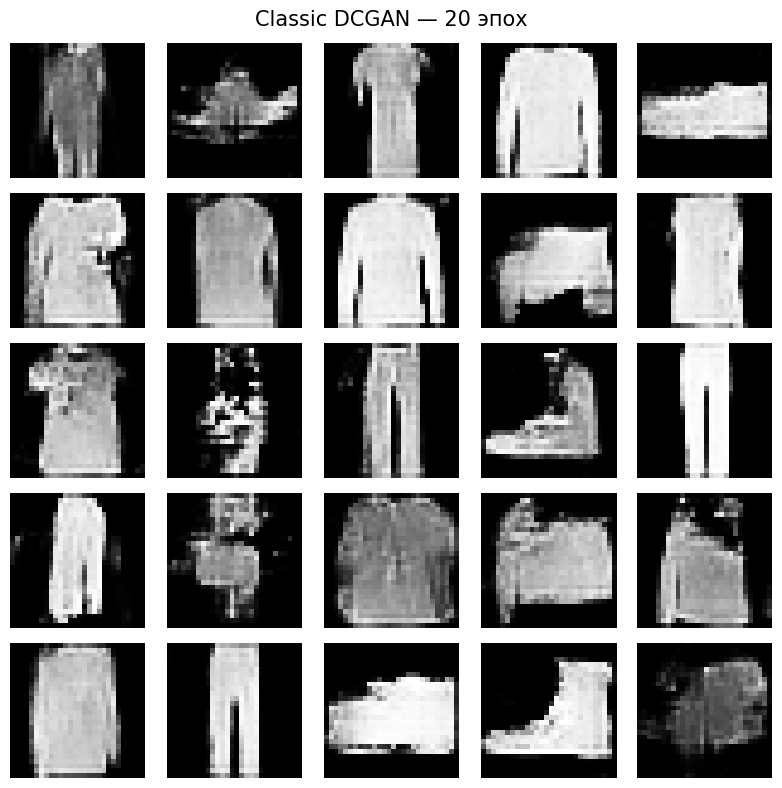


Обучение: Improved DCGAN

Epoch 01/20 | G loss: 0.8838 | D loss: 1.4765
Epoch 02/20 | G loss: 0.8647 | D loss: 1.4177
Epoch 03/20 | G loss: 1.0452 | D loss: 1.1378
Epoch 04/20 | G loss: 1.1039 | D loss: 1.0992
Epoch 05/20 | G loss: 1.0431 | D loss: 1.1872
Epoch 06/20 | G loss: 1.0290 | D loss: 1.1801
Epoch 07/20 | G loss: 0.9871 | D loss: 1.2132
Epoch 08/20 | G loss: 0.9526 | D loss: 1.2344
Epoch 09/20 | G loss: 0.9176 | D loss: 1.2673
Epoch 10/20 | G loss: 0.9150 | D loss: 1.2803
Epoch 11/20 | G loss: 0.8901 | D loss: 1.3037
Epoch 12/20 | G loss: 0.8550 | D loss: 1.3184
Epoch 13/20 | G loss: 0.8368 | D loss: 1.3336
Epoch 14/20 | G loss: 0.8350 | D loss: 1.3318
Epoch 15/20 | G loss: 0.8261 | D loss: 1.3320
Epoch 16/20 | G loss: 0.8292 | D loss: 1.3268
Epoch 17/20 | G loss: 0.8203 | D loss: 1.3292
Epoch 18/20 | G loss: 0.8191 | D loss: 1.3330
Epoch 19/20 | G loss: 0.8182 | D loss: 1.3275
Epoch 20/20 | G loss: 0.8129 | D loss: 1.3333


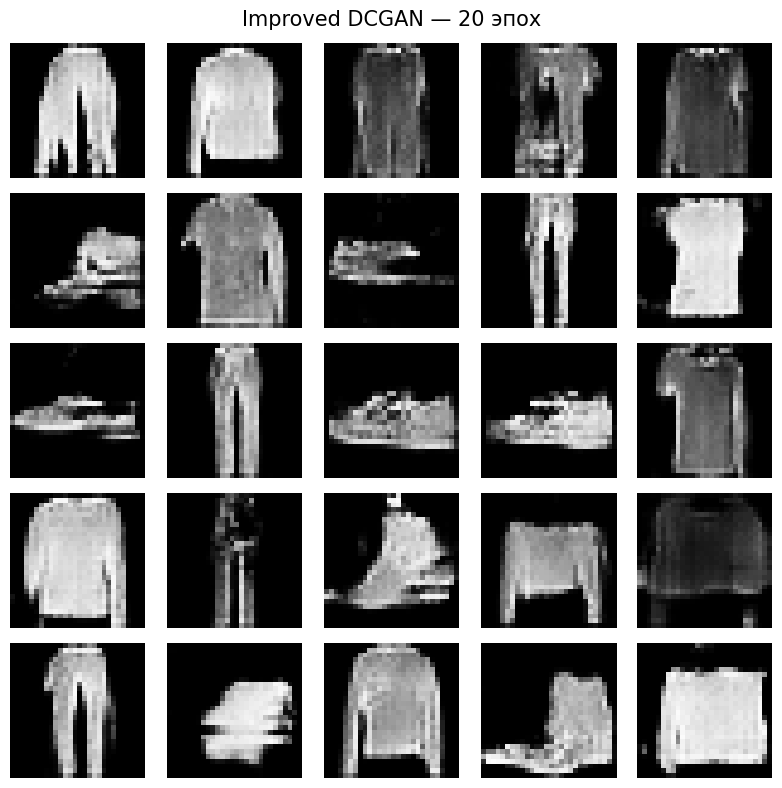

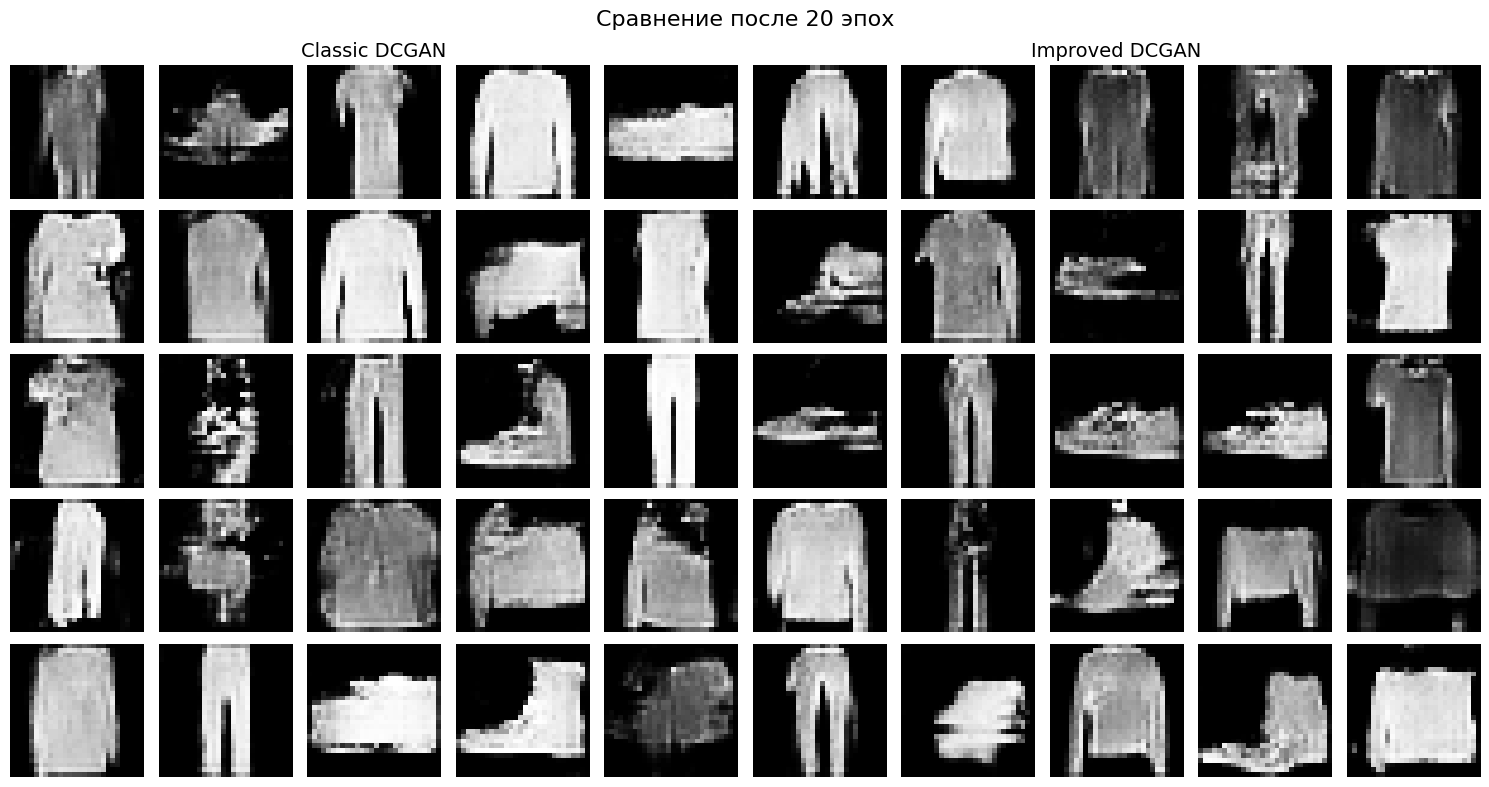

In [4]:
# 25. Функция потерь

cross_entropy = (
    tf.keras.losses.BinaryCrossentropy()
)


def discriminator_loss(
    real_output,
    fake_output,
):

    real_loss = cross_entropy(
        tf.ones_like(
            real_output
        ),
        real_output,
    )

    fake_loss = cross_entropy(
        tf.zeros_like(
            fake_output
        ),
        fake_output,
    )

    return (
        real_loss
        + fake_loss
    )


def generator_loss(
    fake_output,
):

    return cross_entropy(
        tf.ones_like(
            fake_output
        ),
        fake_output,
    )



# 26. Датасет эксперимента

def create_train_dataset():

    return (
        tf.data.Dataset
        .from_tensor_slices(
            gan_images
        )
        .shuffle(
            TRAIN_LIMIT,
            seed=SEED,
            reshuffle_each_iteration=True,
        )
        .batch(
            BATCH_SIZE,
            drop_remainder=True,
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )



# 27. Начальные веса дискриминатора

tf.random.set_seed(
    SEED
)

base_discriminator = (
    create_discriminator()
)

initial_discriminator_weights = (
    base_discriminator.get_weights()
)

print(
    "Начальные веса сохранены."
)


# 28. Контрольные эпохи

CHECKPOINT_EPOCHS = [
    1,
    5,
    10,
    15,
    20,
]


# 29. Обучение GAN

def train_gan(
    generator,
    model_name,
):

    dataset = (
        create_train_dataset()
    )

    discriminator = (
        create_discriminator()
    )

    discriminator.set_weights(
        initial_discriminator_weights
    )

    generator_optimizer = Adam(
        learning_rate=LEARNING_RATE,
        beta_1=BETA_1,
    )

    discriminator_optimizer = Adam(
        learning_rate=LEARNING_RATE,
        beta_1=BETA_1,
    )

    generator_history = []
    discriminator_history = []

    snapshots = {}

    @tf.function
    def train_step(
        real_images,
    ):

        noise = tf.random.normal(
            (
                BATCH_SIZE,
                LATENT_DIM,
            )
        )

        with tf.GradientTape() as gen_tape, \
             tf.GradientTape() as disc_tape:

            generated_images = (
                generator(
                    noise,
                    training=True,
                )
            )

            real_output = (
                discriminator(
                    real_images,
                    training=True,
                )
            )

            fake_output = (
                discriminator(
                    generated_images,
                    training=True,
                )
            )

            gen_loss = generator_loss(
                fake_output
            )

            disc_loss = (
                discriminator_loss(
                    real_output,
                    fake_output,
                )
            )

        generator_gradients = (
            gen_tape.gradient(
                gen_loss,
                generator.trainable_variables,
            )
        )

        discriminator_gradients = (
            disc_tape.gradient(
                disc_loss,
                discriminator.trainable_variables,
            )
        )

        generator_optimizer.apply_gradients(
            zip(
                generator_gradients,
                generator.trainable_variables,
            )
        )

        discriminator_optimizer.apply_gradients(
            zip(
                discriminator_gradients,
                discriminator.trainable_variables,
            )
        )

        return (
            gen_loss,
            disc_loss,
        )

    print()
    print(
        f"Обучение: {model_name}"
    )
    print()

    for epoch in range(
        1,
        EPOCHS + 1,
    ):

        epoch_gen_losses = []
        epoch_disc_losses = []

        for real_batch in dataset:

            gen_loss, disc_loss = (
                train_step(
                    real_batch
                )
            )

            epoch_gen_losses.append(
                float(gen_loss)
            )

            epoch_disc_losses.append(
                float(disc_loss)
            )

        mean_gen_loss = np.mean(
            epoch_gen_losses
        )

        mean_disc_loss = np.mean(
            epoch_disc_losses
        )

        generator_history.append(
            mean_gen_loss
        )

        discriminator_history.append(
            mean_disc_loss
        )

        print(
            f"Epoch "
            f"{epoch:02d}/{EPOCHS} | "
            f"G loss: "
            f"{mean_gen_loss:.4f} | "
            f"D loss: "
            f"{mean_disc_loss:.4f}"
        )

        if epoch in CHECKPOINT_EPOCHS:

            generated = generator(
                fixed_noise,
                training=False,
            )

            snapshots[
                epoch
            ] = generated.numpy()

    return {
        "generator": generator,
        "discriminator": discriminator,
        "generator_loss": generator_history,
        "discriminator_loss": discriminator_history,
        "snapshots": snapshots,
    }



# 30. Обучение Classic DCGAN

tf.random.set_seed(
    SEED
)

classic_result = train_gan(
    classic_generator,
    "Classic DCGAN",
)


# 31. Результат Classic DCGAN

classic_final = (
    classic_result[
        "snapshots"
    ][EPOCHS]
)

plt.figure(
    figsize=(8, 8)
)

for index in range(
    FIXED_COUNT
):

    image = (
        classic_final[
            index,
            :,
            :,
            0
        ]
        + 1.0
    ) / 2.0

    plt.subplot(
        5,
        5,
        index + 1,
    )

    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    plt.axis("off")

plt.suptitle(
    "Classic DCGAN — 20 эпох",
    fontsize=15,
)

plt.tight_layout()
plt.show()


# 32. Обучение Improved DCGAN

tf.random.set_seed(
    SEED
)

improved_result = train_gan(
    improved_generator,
    "Improved DCGAN",
)


# 33. Результат Improved DCGAN

improved_final = (
    improved_result[
        "snapshots"
    ][EPOCHS]
)

plt.figure(
    figsize=(8, 8)
)

for index in range(
    FIXED_COUNT
):

    image = (
        improved_final[
            index,
            :,
            :,
            0
        ]
        + 1.0
    ) / 2.0

    plt.subplot(
        5,
        5,
        index + 1,
    )

    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    plt.axis("off")

plt.suptitle(
    "Improved DCGAN — 20 эпох",
    fontsize=15,
)

plt.tight_layout()
plt.show()



# 34. Сравнение моделей

fig, axes = plt.subplots(
    5,
    10,
    figsize=(15, 8),
)

for index in range(
    FIXED_COUNT
):

    row = index // 5
    column = index % 5

    classic_image = (
        classic_final[
            index,
            :,
            :,
            0
        ]
        + 1.0
    ) / 2.0

    improved_image = (
        improved_final[
            index,
            :,
            :,
            0
        ]
        + 1.0
    ) / 2.0

    axes[
        row,
        column
    ].imshow(
        classic_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[
        row,
        column + 5
    ].imshow(
        improved_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[
        row,
        column
    ].axis("off")

    axes[
        row,
        column + 5
    ].axis("off")

axes[0, 2].set_title(
    "Classic DCGAN",
    fontsize=14,
)

axes[0, 7].set_title(
    "Improved DCGAN",
    fontsize=14,
)

plt.suptitle(
    "Сравнение после 20 эпох",
    fontsize=16,
)

plt.tight_layout()
plt.show()




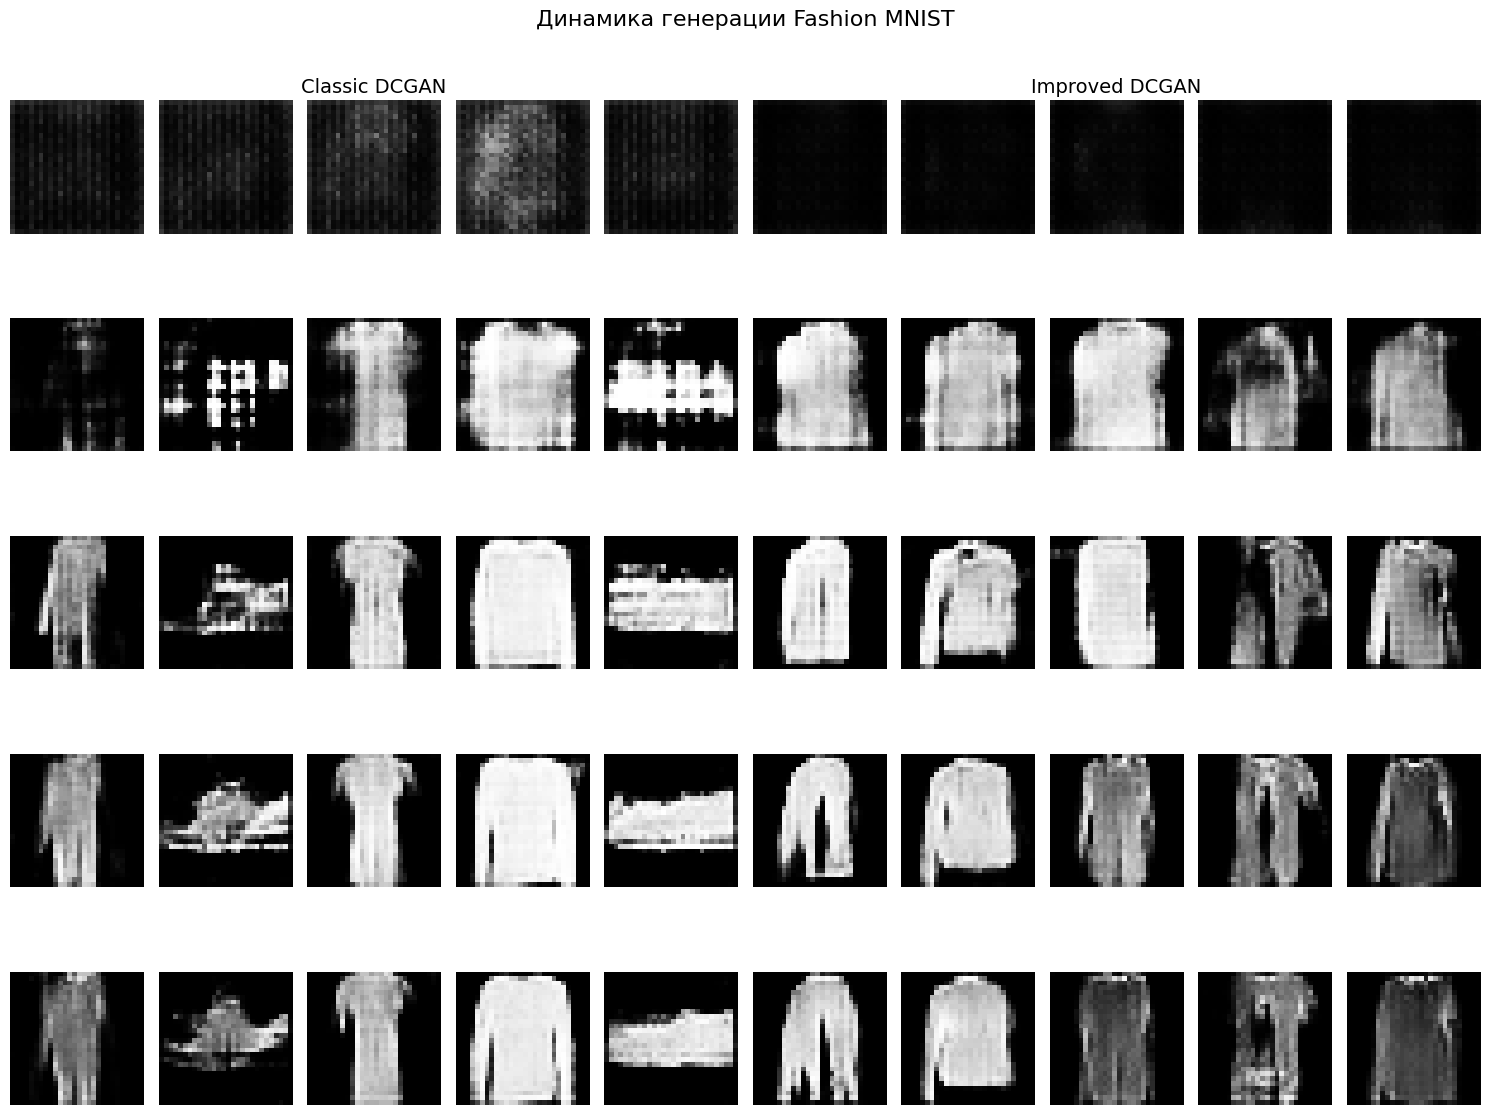

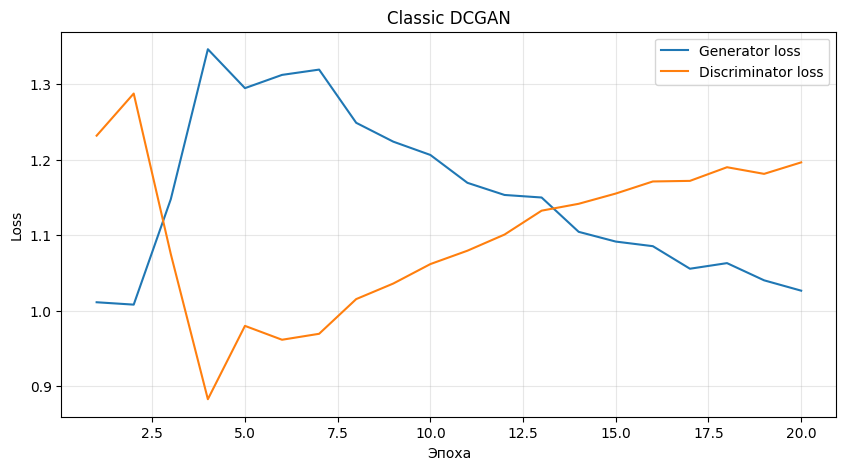

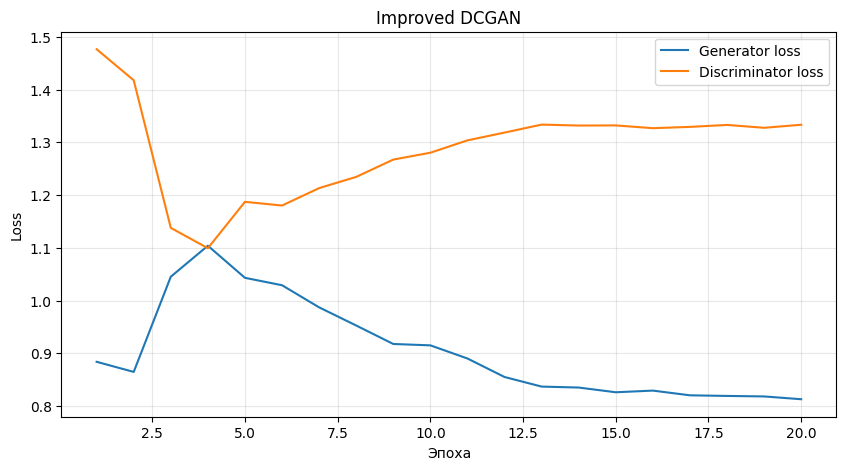

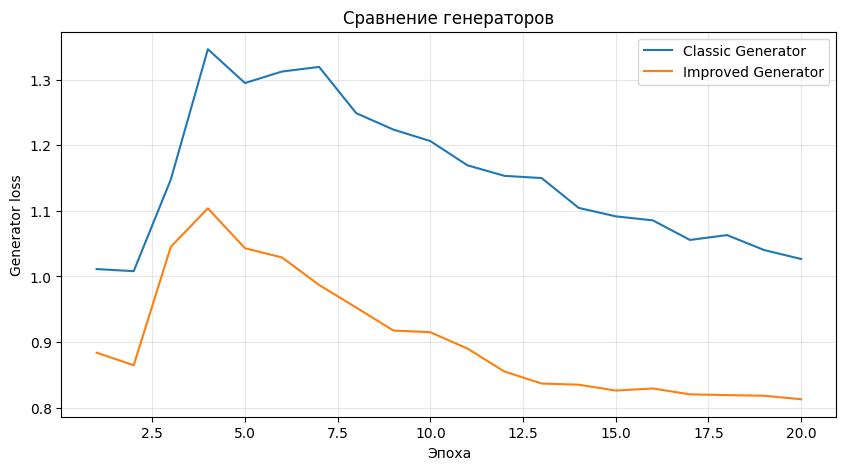

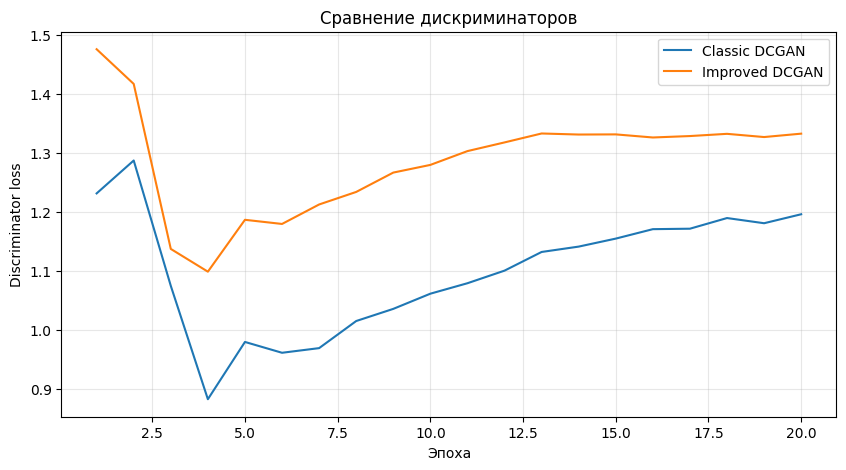

Classic DCGAN
Generator loss: 1.0266
Discriminator loss: 1.1966

Improved DCGAN
Generator loss: 0.8129
Discriminator loss: 1.3333
Classic: (100, 28, 28, 1)
Improved: (100, 28, 28, 1)


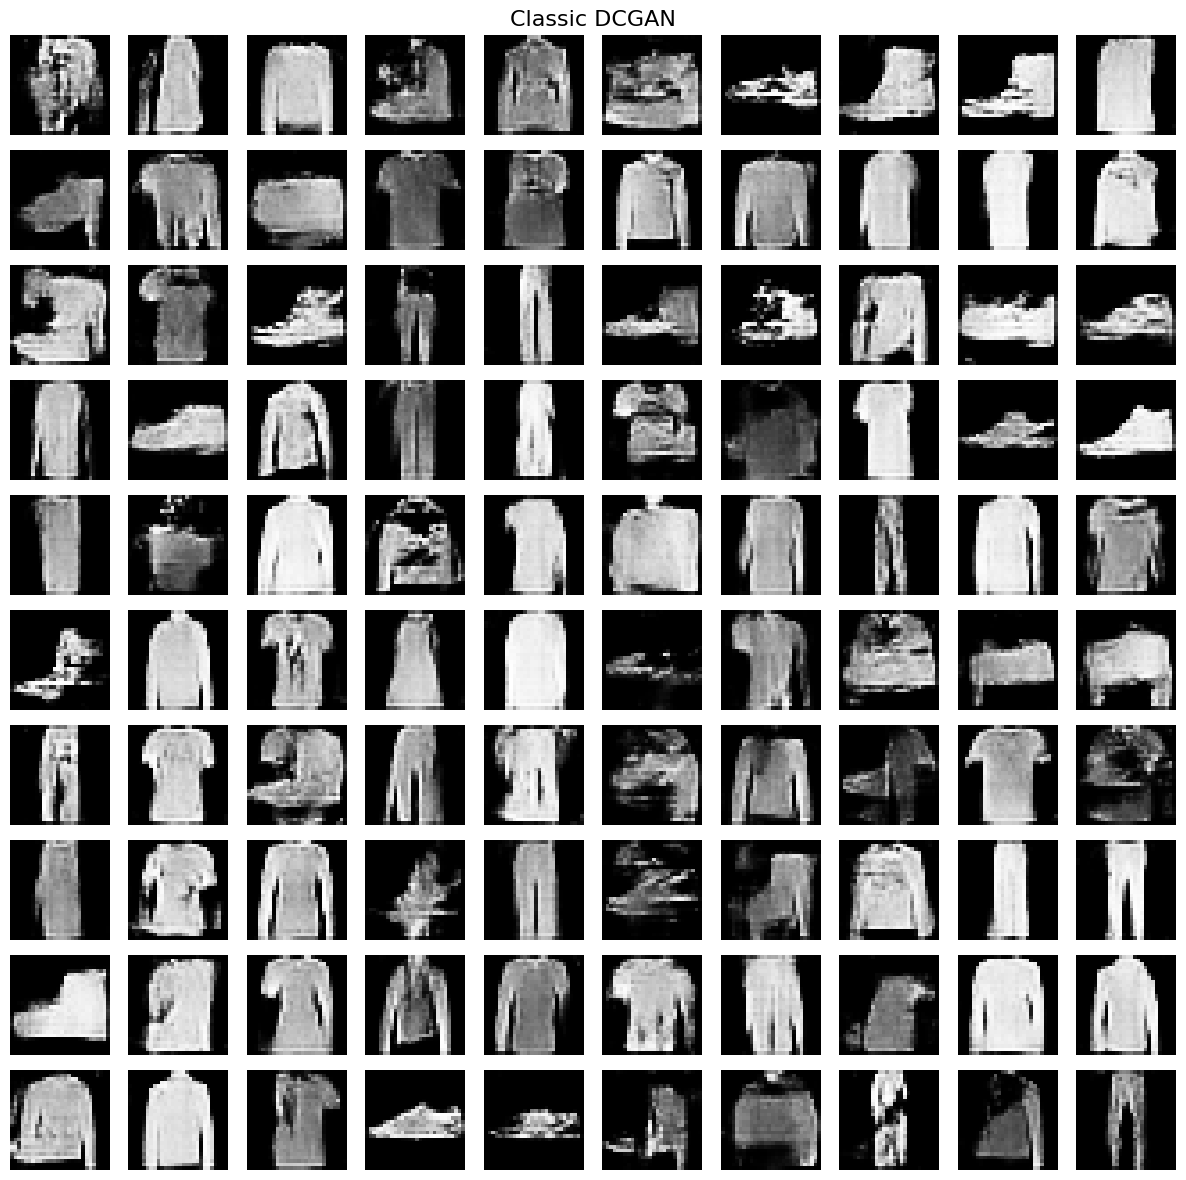

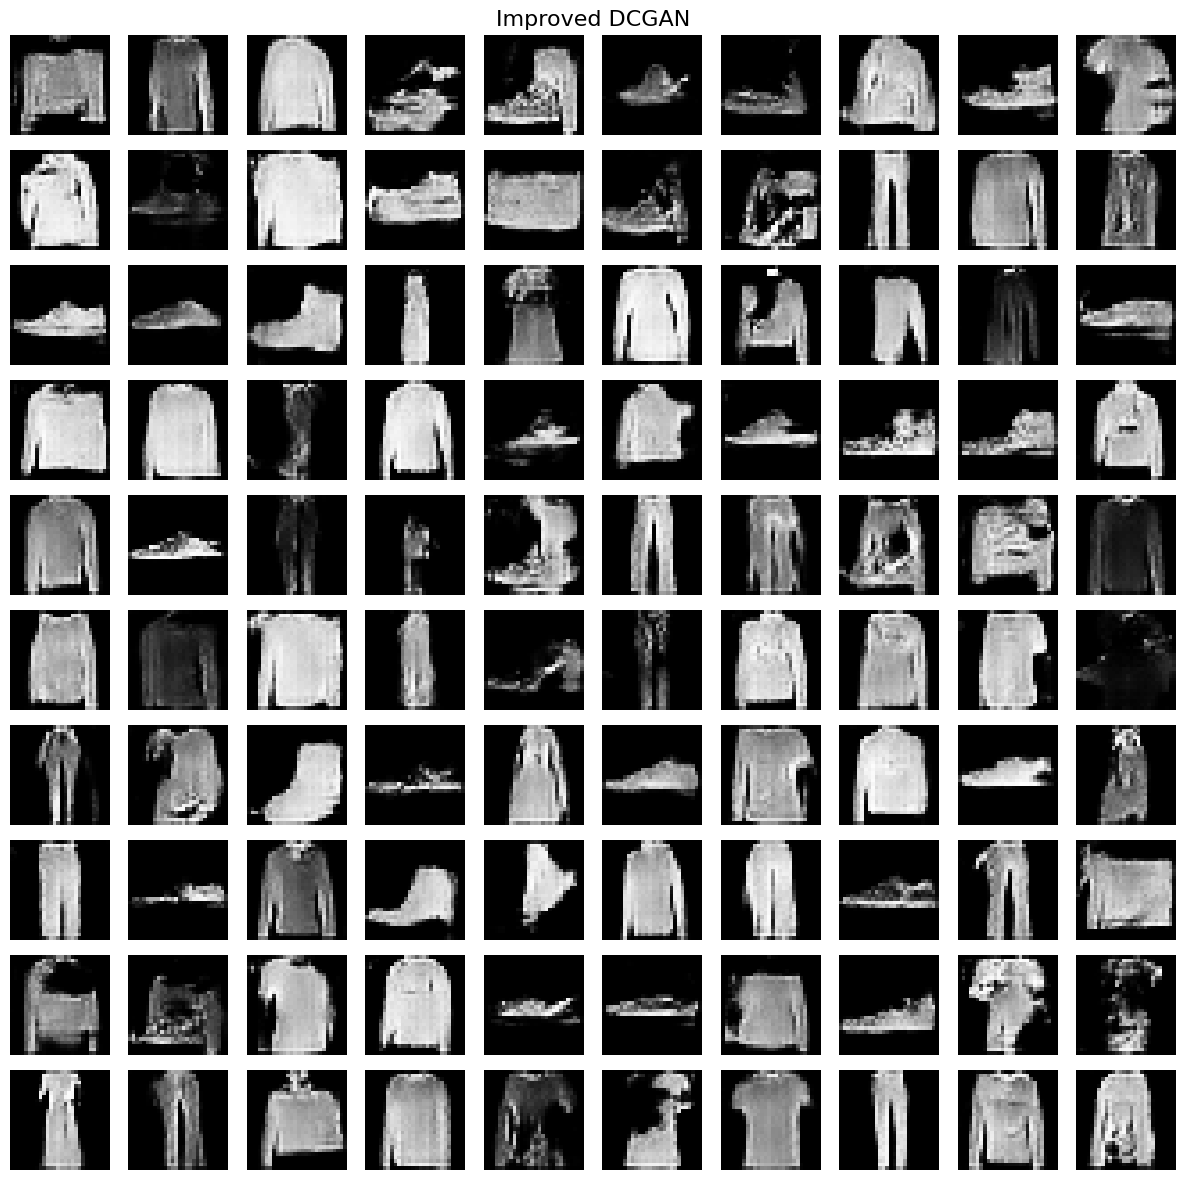

In [5]:
# 35. Сравнение по эпохам

fig, axes = plt.subplots(
    len(CHECKPOINT_EPOCHS),
    10,
    figsize=(15, 12),
)

for row, epoch in enumerate(
    CHECKPOINT_EPOCHS
):

    classic_images = (
        classic_result[
            "snapshots"
        ][epoch]
    )

    improved_images = (
        improved_result[
            "snapshots"
        ][epoch]
    )

    for column in range(5):

        classic_image = (
            classic_images[
                column,
                :,
                :,
                0
            ]
            + 1.0
        ) / 2.0

        improved_image = (
            improved_images[
                column,
                :,
                :,
                0
            ]
            + 1.0
        ) / 2.0

        axes[
            row,
            column
        ].imshow(
            classic_image,
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        axes[
            row,
            column + 5
        ].imshow(
            improved_image,
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        axes[
            row,
            column
        ].axis("off")

        axes[
            row,
            column + 5
        ].axis("off")

    axes[
        row,
        0
    ].set_ylabel(
        f"Эпоха {epoch}",
        fontsize=10,
    )

axes[0, 2].set_title(
    "Classic DCGAN",
    fontsize=14,
)

axes[0, 7].set_title(
    "Improved DCGAN",
    fontsize=14,
)

plt.suptitle(
    "Динамика генерации Fashion MNIST",
    fontsize=16,
)

plt.tight_layout()
plt.show()


# 36. Потери Classic DCGAN

epochs_range = range(
    1,
    EPOCHS + 1,
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_range,
    classic_result[
        "generator_loss"
    ],
    label="Generator loss",
)

plt.plot(
    epochs_range,
    classic_result[
        "discriminator_loss"
    ],
    label="Discriminator loss",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Classic DCGAN"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# 37. Потери Improved DCGAN

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_range,
    improved_result[
        "generator_loss"
    ],
    label="Generator loss",
)

plt.plot(
    epochs_range,
    improved_result[
        "discriminator_loss"
    ],
    label="Discriminator loss",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Improved DCGAN"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# 38. Сравнение Generator Loss

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_range,
    classic_result[
        "generator_loss"
    ],
    label="Classic Generator",
)

plt.plot(
    epochs_range,
    improved_result[
        "generator_loss"
    ],
    label="Improved Generator",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Generator loss"
)

plt.title(
    "Сравнение генераторов"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()



# 39. Сравнение Discriminator Loss

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_range,
    classic_result[
        "discriminator_loss"
    ],
    label="Classic DCGAN",
)

plt.plot(
    epochs_range,
    improved_result[
        "discriminator_loss"
    ],
    label="Improved DCGAN",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Discriminator loss"
)

plt.title(
    "Сравнение дискриминаторов"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# 40. Итоговые значения loss

print(
    "Classic DCGAN"
)

print(
    "Generator loss:",
    f"{classic_result['generator_loss'][-1]:.4f}"
)

print(
    "Discriminator loss:",
    f"{classic_result['discriminator_loss'][-1]:.4f}"
)

print()

print(
    "Improved DCGAN"
)

print(
    "Generator loss:",
    f"{improved_result['generator_loss'][-1]:.4f}"
)

print(
    "Discriminator loss:",
    f"{improved_result['discriminator_loss'][-1]:.4f}"
)


# 41. Новая выборка шума

evaluation_noise = tf.random.normal(
    (
        100,
        LATENT_DIM,
    ),
    seed=123,
)

classic_generated = (
    classic_result[
        "generator"
    ](
        evaluation_noise,
        training=False,
    )
)

improved_generated = (
    improved_result[
        "generator"
    ](
        evaluation_noise,
        training=False,
    )
)

print(
    "Classic:",
    classic_generated.shape
)

print(
    "Improved:",
    improved_generated.shape
)


# 42. Образцы Classic DCGAN

plt.figure(
    figsize=(12, 12)
)

for index in range(100):

    image = (
        classic_generated[
            index,
            :,
            :,
            0
        ]
        + 1.0
    ) / 2.0

    plt.subplot(
        10,
        10,
        index + 1,
    )

    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    plt.axis("off")

plt.suptitle(
    "Classic DCGAN",
    fontsize=16,
)

plt.tight_layout()
plt.show()



# 43. Образцы Improved DCGAN

plt.figure(
    figsize=(12, 12)
)

for index in range(100):

    image = (
        improved_generated[
            index,
            :,
            :,
            0
        ]
        + 1.0
    ) / 2.0

    plt.subplot(
        10,
        10,
        index + 1,
    )

    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    plt.axis("off")

plt.suptitle(
    "Improved DCGAN",
    fontsize=16,
)

plt.tight_layout()
plt.show()




Train: (40000, 28, 28, 1)
Test: (10000, 28, 28, 1)


Model: "Fashion_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.7605 - loss: 0.6687 - val_accuracy: 0.8512 - val_loss: 0.4195
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8589 - loss: 0.3921 - val_accuracy: 0.8702 - val_loss: 0.3610
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8788 - loss: 0.3370 - val_accuracy: 0.8848 - val_loss: 0.3216
Test accuracy: 0.8823
Classic: (1000, 28, 28, 1)
Improved: (1000, 28, 28, 1)
Classic DCGAN: 0.7251
Improved DCGAN: 0.7551
Classic DCGAN
Футболка: 93
Брюки: 107
Свитер: 143
Платье: 106
Пальто: 100
Сандалии: 49
Рубашка: 79
Кроссовки: 119
Сумка: 97
Ботинки: 107

Improved DCGAN
Футболка: 103
Брюки: 120
Свитер: 143
Платье: 95
Пальто: 100
Сандалии: 134
Рубашка: 43
Кроссовки: 103
Сумка: 78
Ботинки: 81
Classic DCGAN: 10 / 10 классов
Improved DCGAN: 10 / 10 классов


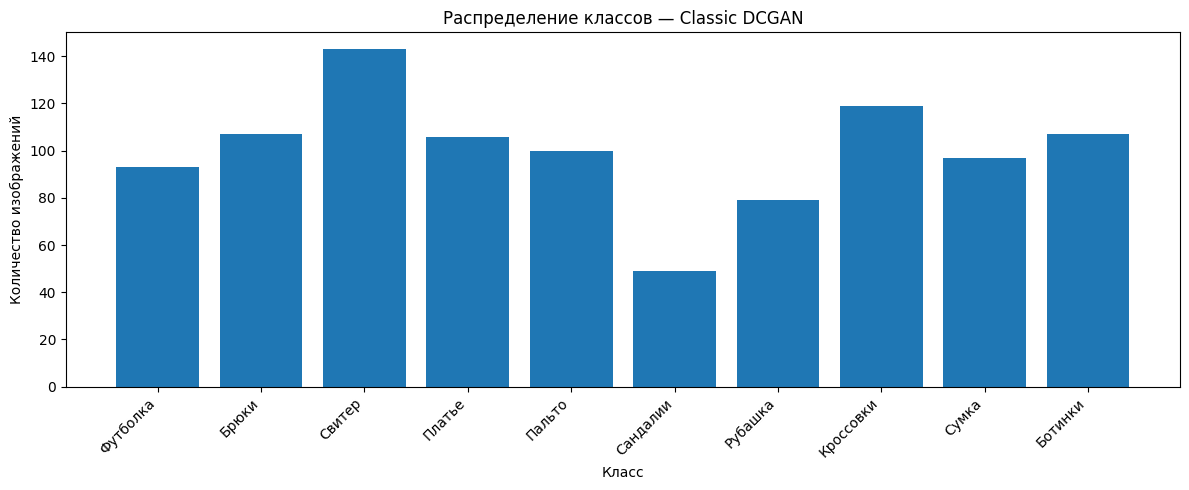

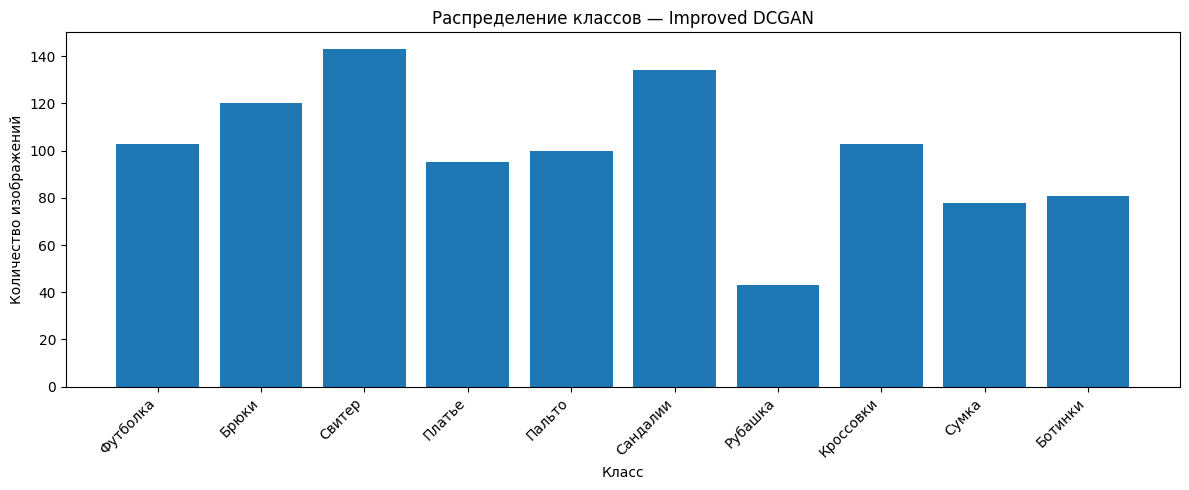

Показатель                              Classic       Improved
--------------------------------------------------------------
Параметры генератора                  1,047,297      1,830,721
Generator loss                           1.0266         0.8129
Discriminator loss                       1.1966         1.3333
Средняя уверенность                      0.7251         0.7551
Представлено классов                         10             10


In [6]:
# 44. Данные для классификатора

classifier_train_images = (
    gan_images + 1.0
) / 2.0

classifier_train_labels = (
    gan_labels
)

classifier_test_images = (
    test_images.astype(
        np.float32
    )
    / 255.0
)

classifier_test_images = (
    np.expand_dims(
        classifier_test_images,
        axis=-1,
    )
)

print(
    "Train:",
    classifier_train_images.shape
)

print(
    "Test:",
    classifier_test_images.shape
)


# 45. Классификатор Fashion MNIST

classifier = Sequential(
    name="Fashion_Classifier"
)

classifier.add(
    Input(
        shape=(28, 28, 1)
    )
)

classifier.add(
    Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        padding="same",
    )
)

classifier.add(
    Conv2D(
        64,
        kernel_size=3,
        strides=2,
        activation="relu",
        padding="same",
    )
)

classifier.add(
    Dropout(0.25)
)

classifier.add(
    Conv2D(
        128,
        kernel_size=3,
        strides=2,
        activation="relu",
        padding="same",
    )
)

classifier.add(
    Flatten()
)

classifier.add(
    Dense(
        128,
        activation="relu",
    )
)

classifier.add(
    Dropout(0.3)
)

classifier.add(
    Dense(
        10,
        activation="softmax",
    )
)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

classifier.summary()



# 46. Обучение классификатора

classifier_history = classifier.fit(
    classifier_train_images,
    classifier_train_labels,
    validation_split=0.1,
    epochs=3,
    batch_size=256,
    verbose=1,
)


# 47. Проверка классификатора

classifier_loss, classifier_accuracy = (
    classifier.evaluate(
        classifier_test_images,
        test_labels,
        verbose=0,
    )
)

print(
    "Test accuracy:",
    f"{classifier_accuracy:.4f}"
)


# 48. Генерация тестовой выборки

EVALUATION_COUNT = 1000

comparison_noise = tf.random.normal(
    (
        EVALUATION_COUNT,
        LATENT_DIM,
    ),
    seed=2026,
)

classic_eval = classic_result[
    "generator"
](
    comparison_noise,
    training=False,
)

improved_eval = improved_result[
    "generator"
](
    comparison_noise,
    training=False,
)

print(
    "Classic:",
    classic_eval.shape
)

print(
    "Improved:",
    improved_eval.shape
)


# 49. Подготовка изображений

classic_eval_images = (
    classic_eval.numpy()
    + 1.0
) / 2.0

improved_eval_images = (
    improved_eval.numpy()
    + 1.0
) / 2.0

classic_eval_images = np.clip(
    classic_eval_images,
    0.0,
    1.0,
)

improved_eval_images = np.clip(
    improved_eval_images,
    0.0,
    1.0,
)


# 50. Оценка генераторов

classic_predictions = (
    classifier.predict(
        classic_eval_images,
        verbose=0,
    )
)

improved_predictions = (
    classifier.predict(
        improved_eval_images,
        verbose=0,
    )
)

classic_classes = np.argmax(
    classic_predictions,
    axis=1,
)

improved_classes = np.argmax(
    improved_predictions,
    axis=1,
)

classic_confidence = np.max(
    classic_predictions,
    axis=1,
)

improved_confidence = np.max(
    improved_predictions,
    axis=1,
)


# 51. Средняя уверенность

classic_mean_confidence = (
    np.mean(
        classic_confidence
    )
)

improved_mean_confidence = (
    np.mean(
        improved_confidence
    )
)

print(
    "Classic DCGAN:",
    f"{classic_mean_confidence:.4f}"
)

print(
    "Improved DCGAN:",
    f"{improved_mean_confidence:.4f}"
)


# 52. Распределение классов

classic_distribution = np.bincount(
    classic_classes,
    minlength=10,
)

improved_distribution = np.bincount(
    improved_classes,
    minlength=10,
)

print(
    "Classic DCGAN"
)

for index, count in enumerate(
    classic_distribution
):

    print(
        f"{class_names[index]}: "
        f"{count}"
    )

print()

print(
    "Improved DCGAN"
)

for index, count in enumerate(
    improved_distribution
):

    print(
        f"{class_names[index]}: "
        f"{count}"
    )



# 53. Разнообразие генерации

MIN_CLASS_COUNT = (
    EVALUATION_COUNT
    * 0.01
)

classic_active_classes = np.sum(
    classic_distribution
    >= MIN_CLASS_COUNT
)

improved_active_classes = np.sum(
    improved_distribution
    >= MIN_CLASS_COUNT
)

print(
    "Classic DCGAN:",
    classic_active_classes,
    "/ 10 классов",
)

print(
    "Improved DCGAN:",
    improved_active_classes,
    "/ 10 классов",
)



# 54. Классы Classic DCGAN

plt.figure(
    figsize=(12, 5)
)

plt.bar(
    class_names,
    classic_distribution,
)

plt.xlabel(
    "Класс"
)

plt.ylabel(
    "Количество изображений"
)

plt.title(
    "Распределение классов — Classic DCGAN"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()



# 55. Классы Improved DCGAN

plt.figure(
    figsize=(12, 5)
)

plt.bar(
    class_names,
    improved_distribution,
)

plt.xlabel(
    "Класс"
)

plt.ylabel(
    "Количество изображений"
)

plt.title(
    "Распределение классов — Improved DCGAN"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()



# 56. Итоговое сравнение

print(
    f"{'Показатель':<32}"
    f"{'Classic':>15}"
    f"{'Improved':>15}"
)

print(
    "-" * 62
)

print(
    f"{'Параметры генератора':<32}"
    f"{classic_params:>15,}"
    f"{improved_params:>15,}"
)

print(
    f"{'Generator loss':<32}"
    f"{classic_result['generator_loss'][-1]:>15.4f}"
    f"{improved_result['generator_loss'][-1]:>15.4f}"
)

print(
    f"{'Discriminator loss':<32}"
    f"{classic_result['discriminator_loss'][-1]:>15.4f}"
    f"{improved_result['discriminator_loss'][-1]:>15.4f}"
)

print(
    f"{'Средняя уверенность':<32}"
    f"{classic_mean_confidence:>15.4f}"
    f"{improved_mean_confidence:>15.4f}"
)

print(
    f"{'Представлено классов':<32}"
    f"{classic_active_classes:>15}"
    f"{improved_active_classes:>15}"
)

In [7]:
# 57. Сравнение результатов

if (
    improved_mean_confidence
    > classic_mean_confidence
):

    confidence_winner = (
        "Improved DCGAN"
    )

else:

    confidence_winner = (
        "Classic DCGAN"
    )


if (
    improved_active_classes
    > classic_active_classes
):

    diversity_winner = (
        "Improved DCGAN"
    )

elif (
    improved_active_classes
    < classic_active_classes
):

    diversity_winner = (
        "Classic DCGAN"
    )

else:

    diversity_winner = (
        "Одинаковый результат"
    )


print(
    "Лучший результат "
    "по уверенности:",
    confidence_winner,
)

print(
    "Лучший результат "
    "по разнообразию:",
    diversity_winner,
)

Лучший результат по уверенности: Improved DCGAN
Лучший результат по разнообразию: Одинаковый результат


Для корректного сравнения обе модели обучались в одинаковых условиях:

- использовались одни и те же 40 000 изображений Fashion MNIST;
- размер латентного пространства составлял 100;
- batch size составлял 256;
- обе модели обучались 20 эпох;
- использовался оптимизатор Adam;
- learning rate составлял 0.0002;
- beta_1 составлял 0.5;
- использовалась Binary Crossentropy;
- архитектура дискриминатора была одинаковой.

Основным различием являлась архитектура генератора.

Для корректного сравнения обе модели обучались в одинаковых условиях:

- использовались одни и те же 40 000 изображений Fashion MNIST;
- размер латентного пространства составлял 100;
- batch size составлял 256;
- обе модели обучались 20 эпох;
- использовался оптимизатор Adam;
- learning rate составлял 0.0002;
- beta_1 составлял 0.5;
- использовалась Binary Crossentropy;
- архитектура дискриминатора была одинаковой.

Основным различием являлась архитектура генератора.